# Jour 4 — Démonstration : suivre un cycle jusqu’à la décision — corrigé

Dans la [théorie](00_comprendre_les_sequences_et_les_rnn_corrige.ipynb), nous avons choisi des poids à la main. Ici, **le réseau va les apprendre à partir d’exemples**. La question ne change pas : vibration puis température (`0`), ou température puis vibration (`1`) ?

Nous allons observer des cycles, préparer une expérience honnête, puis suivre **le même cycle de validation avant et après apprentissage**. Enfin, nous vérifierons d’autres cycles restés à l’écart. Une séquence entre ; une classe sort.


![Les mêmes deux ordres : vibration puis température, ou température puis vibration](../../ressources/illustrations/jour_04/00_mission_deux_ordres.png)


## 1. Que reçoit le réseau ? Observons avant de programmer

La miniature utilisait quatre instants et des événements `0/1`. Les cycles ci-dessous ont **20 instants**, deux capteurs et de petites variations, appelées **bruit**. La température est en °C, la vibration en mm/s. Les événements durent plusieurs instants, mais leur ordre reste la seule différence entre deux versions jumelles.

Les cellules suivantes chargent les outils fournis. NumPy manipule les nombres, Matplotlib les dessine, pandas les présente en tableaux et TensorFlow/Keras exécutent le réseau. Une **graine**, `SEED`, fixe les tirages pour faciliter la reproduction. Nous n’entraînons encore rien.


In [1]:
import os  # Réglages avant de charger les outils de calcul.
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"  # Réduit les messages techniques.
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"  # Utilise le processeur du poste.
os.environ["TF_ENABLE_ONEDNN_OPTS"] = "0"  # Même réglage de calcul entre essais.
os.environ["MPLBACKEND"] = "module://matplotlib_inline.backend_inline"  # Graphiques visibles.

import numpy as np  # Tableaux de nombres et calculs sur leurs axes.
import pandas as pd  # Tableau lisible pour l’historique d’apprentissage.
import matplotlib.pyplot as plt  # Graphiques des séquences et des erreurs.
import tensorflow as tf  # Calcul et apprentissage des réseaux de neurones.
from IPython.display import display  # Affiche les tableaux dans le notebook.

from sklearn.model_selection import train_test_split  # Sépare les cycles.
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

SEED = 42
tf.keras.utils.set_random_seed(SEED)  # Fixe Python, NumPy et TensorFlow.
print("TensorFlow :", tf.__version__)


TensorFlow : 2.21.0


`creer_cycles` fabrique nos exemples. Nous l’importons depuis les fichiers du cours ; il n’est pas nécessaire de comprendre son générateur pour suivre la démonstration. `Path` décrit un dossier ; la recherche ci-dessous retrouve le même outil depuis un support ou son corrigé.


In [2]:
from pathlib import Path  # Décrit les dossiers sur notre ordinateur.
import sys  # Indique à Python où trouver les outils fournis.

# Cherche le dossier du cours, depuis un support ou depuis un corrigé.
ROOT = next((d for d in (Path.cwd(), *Path.cwd().parents)
             if (d / "scripts" / "j4_support.py").is_file()), None)
if ROOT is None:
    raise FileNotFoundError("Ouvrez le dossier complet du cours : scripts/j4_support.py doit être présent.")
if str(ROOT / "scripts") not in sys.path:
    sys.path.insert(0, str(ROOT / "scripts"))
from j4_support import creer_cycles, suivre_memoire  # Outils fournis, expliqués dans le cours.


In [3]:
X, y, groupes = creer_cycles()  # Mesures, bonnes classes et numéro du cycle d’origine.
print("X :", X.shape, "→ séquences, instants, capteurs")
print("y :", y.shape, "→ une bonne classe par séquence")
print("Cycles indépendants :", len(np.unique(groupes)))


X : (800, 20, 2) → séquences, instants, capteurs
y : (800,) → une bonne classe par séquence
Cycles indépendants : 400


Résultat attendu : **800 séquences de forme `(20, 2)`, issues de 400 cycles**. Chaque cycle a deux versions : mêmes mesures, deux événements échangés. `groupes` conserve leur numéro commun.

`X[0, :, 0]` lit le premier cycle (`0`), tous les instants (`:`), et la température (capteur `0`). Le capteur `1` est la vibration. `plt.subplots` crée une zone de dessin par capteur ; `enumerate` associe son numéro à son nom.


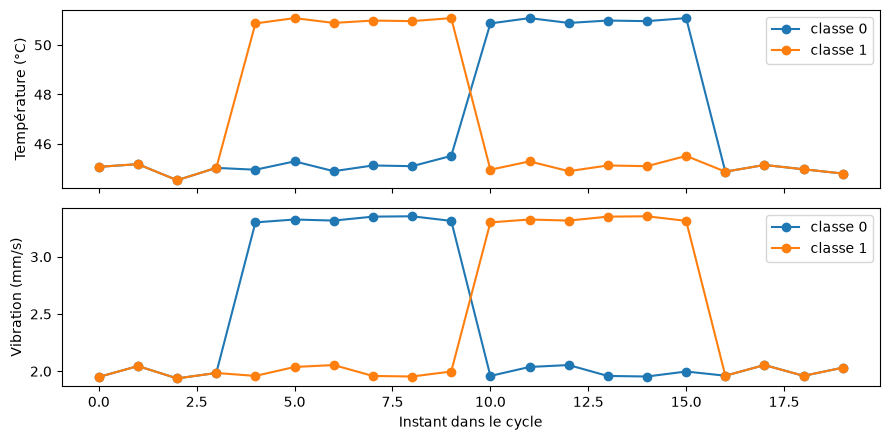

In [4]:
fig, axes = plt.subplots(2, 1, figsize=(9, 4.5), sharex=True)
for capteur, nom in enumerate(["Température (°C)", "Vibration (mm/s)"]):
    for indice in [0, 1]:  # Les deux versions du même cycle.
        axes[capteur].plot(X[indice, :, capteur], marker="o", label=f"classe {y[indice]}")
    axes[capteur].set_ylabel(nom)
    axes[capteur].legend()
axes[-1].set_xlabel("Instant dans le cycle")
plt.tight_layout()
plt.show()


### À vous — prévoir ce qu’une moyenne va cacher

Les deux courbes contiennent les mêmes événements. Leur moyenne permet-elle de reconnaître lequel est arrivé en premier ? Répondez avant de calculer.


In [5]:
explication = "La moyenne conserve un niveau global, mais pas la place des événements. Elle ne distingue pas ces deux versions."
print(explication)


La moyenne conserve un niveau global, mais pas la place des événements. Elle ne distingue pas ces deux versions.


Deux résumés identiques ne peuvent pas justifier deux classes différentes. Cela concerne ces résumés, pas tous les modèles non récurrents.


`np.allclose` vérifie l’égalité à de petits arrondis près. Le calcul des moyennes
utilise `float64`, un format plus précis, pour limiter l’effet de ces arrondis.


In [6]:
# axis=0 parcourt ici les instants d’UN cycle et garde ses deux capteurs séparés.
print("Moyennes identiques :", np.allclose(
    X[0].mean(axis=0, dtype=np.float64), X[1].mean(axis=0, dtype=np.float64)))
print("Dernières mesures identiques :", np.allclose(X[0, -1], X[1, -1]))


Moyennes identiques : True
Dernières mesures identiques : True


Les deux contrôles affichent `True`. Le RNN recevra donc les mesures **dans leur ordre**, pas leur seule moyenne. Une règle comparant les instants des événements pourrait aussi convenir : nous choisissons le RNN pour comprendre comment une mémoire peut s’apprendre, pas pour prouver qu’il est indispensable.

## 2. Comment vérifier un apprentissage honnêtement ?

Il faut d’autres exemples que ceux sur lesquels les poids seront réglés : **train** pour apprendre, **validation** pour surveiller, **test** pour le bilan final. Les deux versions d’un même cycle restent ensemble : les séparer créerait des quasi-copies de part et d’autre.


![400 cycles indépendants : 256 pour apprendre, 64 pour surveiller, 80 pour le test ; les jumeaux restent ensemble](../../ressources/illustrations/jour_04/01_groupes_decoupage.png)


Nous séparons les numéros de cycle avec `train_test_split`. Puis `np.isin` crée un **masque**, une suite de `True/False` qui sélectionne les séquences appartenant à chaque ensemble. Code fourni : concentrez-vous sur **ce qui doit rester ensemble et pourquoi**.


In [7]:
cycles_uniques = np.unique(groupes)  # Une seule entrée par paire de jumeaux.
cycles_train_val, cycles_test = train_test_split(
    cycles_uniques, test_size=0.20, random_state=SEED
)
cycles_train, cycles_val = train_test_split(
    cycles_train_val, test_size=0.20, random_state=SEED
)


# np.isin indique pour chaque séquence si son cycle appartient à l’ensemble voulu.
masque_train = np.isin(groupes, cycles_train)
masque_val = np.isin(groupes, cycles_val)
masque_test = np.isin(groupes, cycles_test)

X_train, y_train = X[masque_train], y[masque_train]
X_val, y_val = X[masque_val], y[masque_val]
X_test, y_test = X[masque_test], y[masque_test]
print("Train / validation / test :", X_train.shape, X_val.shape, X_test.shape)


Train / validation / test : (512, 20, 2) (128, 20, 2) (160, 20, 2)


Les formes attendues sont `(512, 20, 2)`, `(128, 20, 2)` et `(160, 20, 2)`. Les proportions finales sont 64 %, 16 % et 20 % : la validation prend 20 % des 80 % restants.

Température et vibration n’ont pas la même échelle. Pour faciliter les calculs du réseau, la **standardisation** transforme chaque valeur en `(valeur − moyenne) / écart-type`. L’écart-type mesure la dispersion. Nous calculons ces deux statistiques **sur le train seulement**, puis réutilisons la même recette ailleurs. L’ordre ne change pas.


![Chaque capteur garde sa propre moyenne et son propre écart-type, calculés sur le train seulement](../../ressources/illustrations/jour_04/01_standardisation_axes.png)


`axis=(0, 1)` parcourt les cycles et les instants, sans mélanger les capteurs. `keepdims=True` conserve une forme compatible avec les mesures. `float64` calcule les statistiques avec davantage de précision ; `float32` est le format utilisé ensuite par le réseau. NumPy applique la bonne statistique à chaque colonne automatiquement.


In [8]:
# Les axes 0 et 1 parcourent les séquences et le temps, sans mélanger les capteurs.
moyenne_train = X_train.mean(axis=(0, 1), keepdims=True, dtype=np.float64)
ecart_type_train = X_train.std(axis=(0, 1), keepdims=True, dtype=np.float64)

# float64 stabilise les statistiques ; float32 suffit ensuite pour le réseau.
X_train_std = ((X_train - moyenne_train) / ecart_type_train).astype("float32")
X_val_std = ((X_val - moyenne_train) / ecart_type_train).astype("float32")
X_test_std = ((X_test - moyenne_train) / ecart_type_train).astype("float32")
print("Statistiques par capteur :", moyenne_train.shape)
print("Moyennes après transformation :", X_train_std.mean(axis=(0, 1)).round(3))


Statistiques par capteur : (1, 1, 2)
Moyennes après transformation : [-0. -0.]


### À vous — reconnaître le rôle des ensembles

Quel ensemble peut modifier les poids ? Que doit faire la validation ? Répondez en une phrase.


In [9]:
roles = "Le train ajuste les poids ; la validation mesure le résultat pour surveiller l’apprentissage, sans ajuster directement les poids."
print(roles)


Le train ajuste les poids ; la validation mesure le résultat pour surveiller l’apprentissage, sans ajuster directement les poids.


Le choix du moment d’arrêt peut dépendre de la validation. C’est pourquoi nous conservons encore un test séparé pour le bilan final.


## 3. À quoi ressemble le vrai réseau avant d’apprendre ?

Nous retrouvons les trois pièces de la miniature : **lire → garder une mémoire → produire un score**. Cette fois, la mémoire contient 16 nombres, pas un seul. Seize est un choix pour cette démonstration, pas une règle universelle, ni le nombre d’instants conservés.


![Une séquence 20 par 2 entre ; le RNN construit 16 valeurs de mémoire ; la sortie donne un score puis une classe](../../ressources/illustrations/jour_04/01_modele_formes.png)


`Sequential` relie des **couches**, des étapes de calcul. `Input` décrit les 20 instants et 2 capteurs ; `SimpleRNN(16)` lit la suite et renvoie sa dernière mémoire. `Dense(1)` combine cette mémoire en un nombre ; `sigmoid` le transforme en score entre 0 et 1 pour la classe `1`.

`tanh` est la transformation bornée entre −1 et 1 déjà rencontrée dans la miniature. Les poids et biais de ces calculs seront appris. Au départ, ils ne sont **pas encore adaptés à nos exemples**.


In [10]:
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=X_train_std.shape[1:]),  # Temps et capteurs.
    tf.keras.layers.SimpleRNN(16, activation="tanh"),  # Mémoire de 16 nombres.
    tf.keras.layers.Dense(1, activation="sigmoid"),  # Score de la classe 1.
], name="ordre_deux_evenements")


Choisissons maintenant notre **cycle fil rouge**, le premier de validation. Il ne servira pas à corriger les poids. `[0:1]` conserve un lot d’une séquence, de forme `(1, 20, 2)` ; le réseau attend toujours cet axe de lot.

`predict` effectue une lecture sans apprendre. `[0, 0]` récupère son unique score. Au seuil `0.5`, un score inférieur donne la classe `0`, sinon la classe `1`.


In [11]:
cycle_fil = X_val_std[0:1]  # Toujours CE cycle dans les comparaisons avant/après.
vraie_classe_fil = int(y_val[0])
score_avant = float(model.predict(cycle_fil, verbose=0)[0, 0])
memoires_avant, _ = suivre_memoire(model, cycle_fil)  # Outil d’observation fourni.
poids_avant = [p.copy() for p in model.get_weights()]  # Copie des réglages avant apprentissage.
print("Bonne classe :", vraie_classe_fil)
print("Avant apprentissage : score =", round(score_avant, 3), "; classe =", int(score_avant >= 0.5))


Bonne classe : 0
Avant apprentissage : score = 0.303 ; classe = 0


Cette réponse peut être juste **par hasard**. Une réussite isolée ne prouve pas que les poids ont appris. Nous allons les régler sur le train, puis relire exactement ce cycle sans changer ses mesures.

## 4. Qu’est-ce qui change pendant l’apprentissage ?

Pendant une lecture, les poids sont fixes et la mémoire évolue. Pendant l’apprentissage, on compare les scores aux bonnes classes et on ajuste les poids : ceux de la mémoire **et** ceux de la sortie.


![Lecture à poids fixes puis comparaison aux bonnes classes et correction des poids sur les lots du train](../../ressources/illustrations/jour_04/00_deux_boucles.png)


`compile` prépare les règles, sans encore apprendre. La **perte** chiffre l’erreur : `binary_crossentropy` pénalise notamment une réponse fausse très assurée. **Adam** est l’optimiseur qui ajuste les poids ; son `learning_rate` règle l’ampleur des corrections. L’**accuracy** mesure la proportion de classes correctes, mais c’est la perte que l’entraînement cherche à réduire.


In [12]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.003),  # Ampleur des corrections.
    loss="binary_crossentropy",  # Comparer le score à la bonne classe.
    metrics=["accuracy"],  # Compter aussi les réponses correctes.
)


`fit` lance l’apprentissage. Une **époque** est un passage complet sur le train. Un **lot** (*batch*) regroupe ici au plus 32 séquences avant une correction des poids ; chacune commence avec sa propre mémoire à zéro.

Nous surveillons aussi la perte de validation, `val_loss`. `EarlyStopping` arrête après cinq époques sans amélioration et restaure les meilleurs poids observés. Il ne consulte pas le test.


In [13]:
arret = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=5, restore_best_weights=True
)
history = model.fit(
    X_train_std, y_train,  # Seul cet ensemble modifie les poids.
    validation_data=(X_val_std, y_val),  # La validation mesure, sans apprendre.
    epochs=35, batch_size=32, callbacks=[arret], verbose=0,
)
print("Époques exécutées :", len(history.history["loss"]))


Époques exécutées : 35


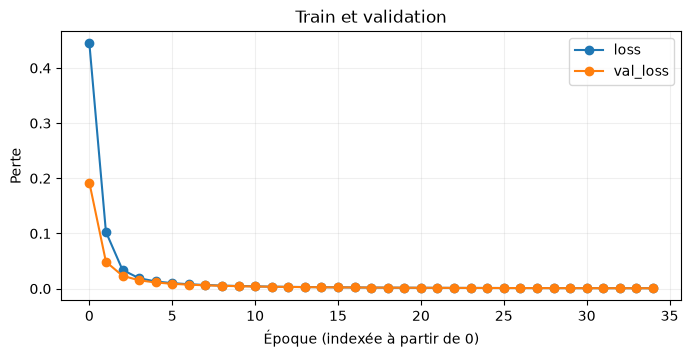

In [14]:
historique = pd.DataFrame(history.history)  # Une ligne par époque.
axe = historique[["loss", "val_loss"]].plot(figsize=(8, 3.5), marker="o")
axe.set(xlabel="Époque (indexée à partir de 0)", ylabel="Perte", title="Train et validation")
axe.grid(alpha=0.2)
plt.show()


Les courbes proviennent de **votre exécution**, pas d’un résultat imposé. Une baisse sur train et validation est encourageante. Si seule la perte du train baisse et celle de validation remonte durablement, le réseau se spécialise trop sur ses exemples : c’est le **surapprentissage**.

## 5. Relisons exactement le même cycle

Nous gardons les mesures de `cycle_fil` et la même bonne réponse. La différence vient maintenant des poids ajustés. La mémoire est recalculée depuis zéro ; nous ne reprenons pas une mémoire laissée par l’entraînement.


In [15]:
score_apres = float(model.predict(cycle_fil, verbose=0)[0, 0])
bilan_cycle = pd.DataFrame({
    "moment": ["avant apprentissage", "après apprentissage"],
    "score classe 1": [score_avant, score_apres],
    "classe annoncée": [int(score_avant >= 0.5), int(score_apres >= 0.5)],
    "bonne classe": [vraie_classe_fil, vraie_classe_fil],
})
display(bilan_cycle)  # Deux lectures des mêmes mesures.
print("Au moins un poids a changé :", any(
    not np.array_equal(avant, apres)
    for avant, apres in zip(poids_avant, model.get_weights())
))


,moment,score classe 1,classe annoncée,bonne classe
0,avant apprentissage,0.302632,0,0
1,après apprentissage,0.000688,0,0


Au moins un poids a changé : True


Regardons aussi la mémoire, pour relier Keras au calcul de la théorie. L’outil fourni `suivre_memoire` reprend les **vrais poids du réseau** et rejoue chaque instant, sans apprentissage. Le contrôle ci-dessous vérifie que son score final retrouve celui de `predict` ; `assert_allclose` tolère seulement de petits écarts numériques.

Sur l’image calculée, une ligne est un instant et une colonne l’un des 16 nombres de mémoire. La couleur représente sa valeur entre −1 et 1. **Une colonne n’est pas un capteur et n’a pas un sens physique attribué à l’avance.**


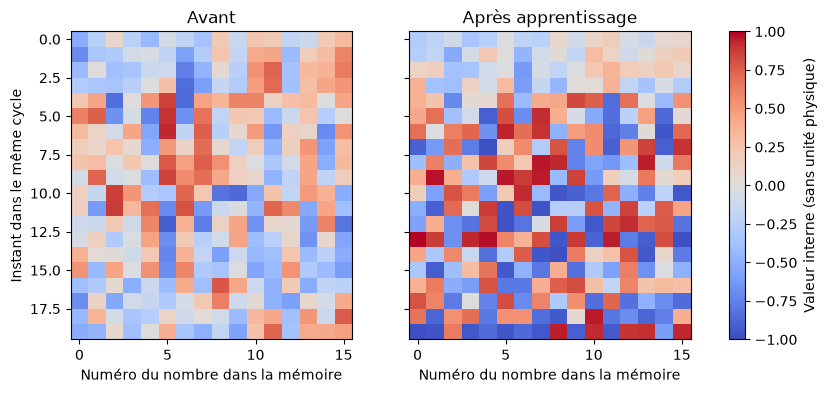

Contrôle réussi : le calcul avec les vrais poids retrouve le score de Keras.


In [16]:
memoires_apres, score_recalcule = suivre_memoire(model, cycle_fil)
np.testing.assert_allclose(score_recalcule, score_apres, atol=1e-5)
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)
for axe, etats, titre in zip(axes, [memoires_avant, memoires_apres], ["Avant", "Après apprentissage"]):
    vue = axe.imshow(etats, aspect="auto", cmap="coolwarm", vmin=-1, vmax=1)
    axe.set(title=titre, xlabel="Numéro du nombre dans la mémoire")
axes[0].set_ylabel("Instant dans le même cycle")
fig.colorbar(vue, ax=axes, label="Valeur interne (sans unité physique)")
plt.show()
print("Contrôle réussi : le calcul avec les vrais poids retrouve le score de Keras.")


### À vous — expliquer l’avant et l’après

Les mesures sont identiques. Qu’est-ce qui explique la différence de score ? Pourquoi la mémoire peut-elle différer alors qu’elle démarre à zéro dans les deux cas ?


In [17]:
changement = "Les poids ont changé. Les mêmes mesures passent donc dans une règle différente : elle construit une autre mémoire, puis un autre score."
print(changement)


Les poids ont changé. Les mêmes mesures passent donc dans une règle différente : elle construit une autre mémoire, puis un autre score.


L’apprentissage ne stocke pas simplement le dernier état d’un cycle. Il règle une manière de traiter de nouveaux cycles.


## 6. Que se passe-t-il si l’ordre change ?

Les deux premières séquences de validation sont des jumeaux : nos masques ont conservé leur ordre initial. Les événements changent de place, pas leurs niveaux. **Avant d’exécuter : quelles classes attendez-vous pour les deux versions ?**


,bonne classe,score classe 1,classe annoncée
0,0,0.000688,0
1,1,0.999309,1


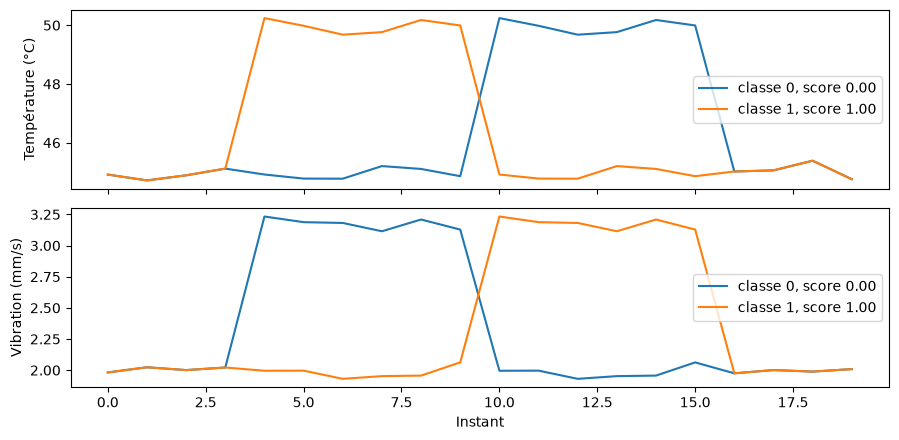

In [18]:
scores_paire = model.predict(X_val_std[:2], verbose=0).ravel()  # Un tableau de deux scores.
display(pd.DataFrame({"bonne classe": y_val[:2], "score classe 1": scores_paire,
                      "classe annoncée": (scores_paire >= 0.5).astype("int32")}))
fig, axes = plt.subplots(2, 1, figsize=(9, 4.5), sharex=True)
for capteur, nom in enumerate(["Température (°C)", "Vibration (mm/s)"]):
    for i in [0, 1]:
        axes[capteur].plot(X_val[i, :, capteur], label=f"classe {y_val[i]}, score {scores_paire[i]:.2f}")
    axes[capteur].set_ylabel(nom)
    axes[capteur].legend()
axes[-1].set_xlabel("Instant")
plt.tight_layout()
plt.show()


Si les deux classes sont reconnues, c’est un contrôle utile sur cette paire, **pas une preuve que le réseau comprend tous les ordres possibles**. Nos événements occupent des positions régulières dans des cycles artificiels. Le score n’est pas une garantie de fiabilité.

## 7. Réussit-il aussi sur les cycles réservés ?

Nous ne changeons plus les réglages. `predict` lit le test ; `.ravel()` met les scores dans un tableau à un axe ; `>= 0.5` donne les classes. La **matrice de confusion** compte les réponses : lignes = vraies classes, colonnes = classes annoncées. Sa diagonale contient les réponses justes, les deux autres cases les confusions d’ordre.


Réponses correctes : 160 / 160
Accuracy test : 1.0


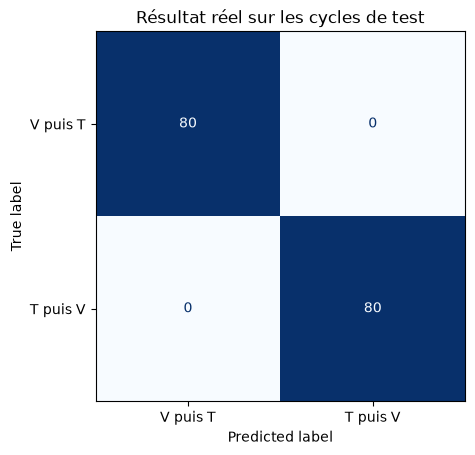

In [19]:
probabilites_test = model.predict(X_test_std, verbose=0).ravel()
predictions_test = (probabilites_test >= 0.5).astype("int32")
bonnes_reponses = int(np.sum(predictions_test == y_test))
print("Réponses correctes :", bonnes_reponses, "/", len(y_test))
print("Accuracy test :", round(bonnes_reponses / len(y_test), 3))
ConfusionMatrixDisplay.from_predictions(
    y_test, predictions_test, labels=[0, 1], display_labels=["V puis T", "T puis V"],
    cmap="Blues", colorbar=False,
)
plt.title("Résultat réel sur les cycles de test")
plt.show()


Lisez d’abord les erreurs : quel ordre est confondu avec l’autre ? Un très bon résultat est possible sur cette expérience volontairement simple. Il ne mesure pas une capacité à diagnostiquer des pannes réelles.

## 8. Ce que vous devez pouvoir raconter

**Le réseau lit les mesures dans l’ordre. Ses poids déterminent comment il met à jour une mémoire, puis transforme le résumé final en score. L’apprentissage ajuste ces poids sur le train ; la validation surveille et le test mesure le résultat final.**

Les mêmes poids sont réutilisés à chaque instant. La mémoire repart de zéro pour chaque cycle. Dans l’[exercice de l’après-midi](02_exercice_rnn_capteurs_corrige.ipynb), vous reprendrez ce raisonnement avec un troisième capteur et de petites décisions à justifier.

<details>
<summary>Pour aller plus loin : où retrouver les détails techniques ?</summary>

Le [fichier d’outils](../../scripts/j4_support.py) contient le générateur et le calcul de la mémoire. Son opérateur `@` combine les contributions des mesures et de l’état précédent avec les poids appris. Ce détail de calcul n’est pas nécessaire pour réaliser l’atelier.

Une référence limitée à la moyenne ou au dernier instant ne peut pas distinguer nos jumeaux : elle obtient au mieux 50 % sur ce jeu équilibré. Cela ne prouve pas qu’un RNN est la meilleure solution ; une règle sur l’ordre des événements constitue aussi une référence possible.

Le rapport complet de classification ajoute précision (parmi les classes annoncées, celles qui sont justes), rappel (parmi les classes réelles, celles retrouvées) et F1 (un résumé des deux). Ces indicateurs prolongent la lecture des erreurs ; ils ne changent pas le mécanisme du RNN.
</details>
